# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

Our baseline model is a multiple linear regression in which the target variable is treated as continuous.


# Import modules

In [1]:
# Import modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lemmy
import nltk
import re
import os
from matplotlib.lines import Line2D
# nltk.download('stopwords')
from nltk.corpus import stopwords                                           
from sklearn.model_selection import learning_curve
from sklearn.decomposition import LatentDirichletAllocation                 
from sklearn.feature_extraction.text import CountVectorizer                 
from afinn import Afinn
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, PoissonRegressor, Lasso
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load the Dataframe

In [2]:
# Load DataFrame
df = pd.read_csv('data/df_after_variable.csv')

# See dataframe
df

,Title,Start Date,Votes,File Number,Body Text,Num Coauthors,Lifetime,Month_2,Month_3,Month_4,...,Title Uppercase Count,Body Text Uppercase Count,Title Lowercase Count,Body Text Lowercase Count,Body Text LIX Score,Distance to parliament km,Big city,Title All Uppercase,Sentiment_neutral,Sentiment_positive
0,Afskaf inklusionsloven,2024-08-15,39,FT-18153,For at forbedre undervisningen og sikre optima...,3,3,False,False,False,...,1,18,20,2556,59.349155,278.896623,True,False,False,True
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,FT-18099,Forslaget drejer sig om regler for fartbøder v...,3,12,False,False,False,...,2,17,44,999,40.803930,355.768312,False,False,False,True
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,FT-18075,Dressurridning som konkurrencesport er en spor...,3,12,False,False,False,...,1,40,38,1864,40.113388,13.285377,False,False,False,False
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,FT-18046,Vi stiller et forslag om ændring af reglerne f...,3,12,False,False,False,...,1,14,87,1429,50.907995,291.079559,False,False,False,False
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,FT-18044,Jeg forslår at der etableres en pligt til at a...,3,23,False,False,False,...,2,11,25,544,30.552941,338.944018,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,Opæhvelse af begrænsning på 45 knallerter,2018-01-30,189,FT-00139,Jeg stiller hermed forslag om at ophævelsen af...,3,180,False,False,False,...,1,6,33,426,43.400000,110.013938,False,False,False,False
1843,Automatisk førtidspension til personer der har...,2018-01-30,66,FT-00059,Forslaget er at man automatisk giver førtidspe...,4,180,False,False,False,...,1,6,108,944,53.763418,390.978286,False,False,False,False
1844,POLITISK FORSLAG TIL HØRING I FOLKETINGET OM Æ...,2018-01-30,597,FT-00034,"Lovforslaget går i sin enkelhed ud på, at sikr...",3,180,False,False,False,...,88,13,0,1385,33.292443,149.484204,False,True,False,True
1845,"Statsborgerskab til unge mennesker, som er fød...",2018-01-30,6263,FT-00067,Folketinget pålægger regeringen at genindføre ...,3,180,False,False,False,...,2,46,88,3886,49.983954,46.247679,False,False,False,True


## Step 1: Latent Dirichlet Allocation

Set consistent random state, max iteration count and test size:

In [3]:
random_state = 12
max_iter = 50000
test_size_globale = 1/5

Lemmatize the documents:

In [4]:
# Danish stopwords
stop = stopwords.words('danish')
extra_stopwords = ["per", "stk", "100", "2020", "begge", "uge", "50"]

# Extend the stopwords list with extra_stopwords
stop.extend(extra_stopwords)

# Lemmatizer in Danish
lemmatizer = lemmy.load("da")

# Tokenization function to handle punctuation
def tokenize(text):
    return re.findall(r'\b\w+\b', text)

# Lemmatize and process each document in the "Body Text" column
body_tokens_lem = [
    " ".join(
        [lemmatizer.lemmatize("", token.lower())[0] if lemmatizer.lemmatize("", token.lower()) else token.lower()
         for token in tokenize(document) if token.lower() not in stop]
    )
    for document in df["Body Text"]
]

# Print the first few rows to verify
print("Lemmatized Tokens:", body_tokens_lem[0])

Lemmatized Tokens: forbedre undervisning sikre optimal støtte elevere særlig behov foreslå afskaffe inklusionslov stede genindføre styrke specialtilbud folkeskole indebære omlægning ressource se flere middel afsætte specialskole specialklasse elevere særlig behov kunne få skræddersy undervisning støtte uddanne specialist desuden etablere flere fleksibel ordning elevere kunne modtage kombination specialpædagogisk støtte undervisning almindelig klasse hensigtsmæssig udvikling sikre få nødvendig faglig social støtte samtidig højere grade inkludere skole fællesskab præmis lære kompetence burde opgradere gennem efteruddannelse se god ruste identificere håndtere elevere særlig behov desuden burde etablere stærk samarbejdsstrukturere mellem lærer pædagog specialist sikre helhedsorienteret tilgang hver enkel elev behov ændring sikre elevere modtage undervisning støtte niveau god fremme læring trivsel lære kunne fokusere lever høj undervisningskvalitet inklusionslov indføre 2012 formål inkluder

In [5]:
# To test added stopwords
unique = set(stop) 
print("How many unqiue stopwords: ", len(unique))
print("and how many total stopwords: ", len(stop))

How many unqiue stopwords:  101
and how many total stopwords:  101


Now we split the data and apply LDA for topic modeling:

In [6]:
# Splitting string dataset into development- and test data.
body_dev, body_test = train_test_split(body_tokens_lem, test_size=test_size_globale, random_state=random_state)
body_dev_title, body_test_title = train_test_split(df["Title"], test_size=test_size_globale, random_state=random_state)

# Set min_df to 3, max_df to 0.1 for bag of words
count = CountVectorizer(min_df=3, max_df=0.1, max_features=50000)
bag = count.fit_transform(body_dev)

# Define the unsupervised machine learning model
lda = LatentDirichletAllocation(n_components=9, random_state=random_state)
borgerforslag_topics = lda.fit_transform(bag)

# Displaying topics
n_top_words = 7
word_names = count.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print("Topic %d:" % (topic_idx + 1))
    print(" ".join([word_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]))

# Assign the most relevant topic to each document in the development set
doc_labels = []
for i, topic_dist in enumerate(borgerforslag_topics):
    document_index = body_dev_title.index[i]
    most_probable_topic = np.argmax(topic_dist) + 1
    if topic_dist[most_probable_topic - 1] > 0.1:
        doc_labels.append((document_index, most_probable_topic))


Topic 1:
følelse aarhus skole container eu bæredygtig folkeskole
Topic 2:
virksomhed israel international ukraine who eu gaza
Topic 3:
undervisning skole elevere elev digital eksamen lære
Topic 4:
bile køre parti grøn trafik co2 transport
Topic 5:
skatte fødevare landbrug produkt cannabis uddannelse gammel
Topic 6:
syg sygdom mand psykisk behandling barsel risiko
Topic 7:
statsborgerskab flygtning uddannelse statsborger opholdstilladelse lande opholde
Topic 8:
hund dy virksomhed fyrværkeri politi natur reklamere
Topic 9:
kvinde behandling socialrådgiver føde hjem fejle afgørelse


Below we predict catagories on lda trained on body_dev:

In [7]:
# Process the test set
bag_test = count.transform(body_test)
borgerforslag_topics_test = lda.transform(bag_test)

# Assign the most relevant topic to each document in the test set
doc_labels_test = []
for i, topic_dist in enumerate(borgerforslag_topics_test):
    document_index = body_test_title.index[i]
    most_probable_topic = np.argmax(topic_dist) + 1
    
    # Apply threshold if needed, check that topic_dist is non-empty
    if len(topic_dist) > 0 and topic_dist[most_probable_topic - 1] > 0.1:
        doc_labels_test.append((document_index, most_probable_topic))


We now create dummies and add as variables to df:

In [8]:
# Creating and concatenating DataFrames
merged_topics = pd.concat(
    [pd.DataFrame(doc_labels, columns=['Index', 'Topic']).set_index('Index'),
     pd.DataFrame(doc_labels_test, columns=['Index', 'Topic']).set_index('Index')],
    ignore_index=False  # Keep the index as it is, rather than reindexing
)

# Merge df with merged_topics on the index
df = df.join(merged_topics, how='left')

# Add dummy variables for topics directly after merging
df = df.join(pd.get_dummies(df['Topic'], drop_first=True, prefix="Topic"))

# Drop the 'Topic' column after creating dummies
df = df.drop(columns='Topic')

# Display the first row of the updated DataFrame
df


,Title,Start Date,Votes,File Number,Body Text,Num Coauthors,Lifetime,Month_2,Month_3,Month_4,...,Sentiment_neutral,Sentiment_positive,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,Afskaf inklusionsloven,2024-08-15,39,FT-18153,For at forbedre undervisningen og sikre optima...,3,3,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,FT-18099,Forslaget drejer sig om regler for fartbøder v...,3,12,False,False,False,...,False,True,False,False,False,False,False,True,False,False
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,FT-18075,Dressurridning som konkurrencesport er en spor...,3,12,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,FT-18046,Vi stiller et forslag om ændring af reglerne f...,3,12,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,FT-18044,Jeg forslår at der etableres en pligt til at a...,3,23,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,Opæhvelse af begrænsning på 45 knallerter,2018-01-30,189,FT-00139,Jeg stiller hermed forslag om at ophævelsen af...,3,180,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1843,Automatisk førtidspension til personer der har...,2018-01-30,66,FT-00059,Forslaget er at man automatisk giver førtidspe...,4,180,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1844,POLITISK FORSLAG TIL HØRING I FOLKETINGET OM Æ...,2018-01-30,597,FT-00034,"Lovforslaget går i sin enkelhed ud på, at sikr...",3,180,False,False,False,...,False,True,False,False,False,False,False,False,False,True
1845,"Statsborgerskab til unge mennesker, som er fød...",2018-01-30,6263,FT-00067,Folketinget pålægger regeringen at genindføre ...,3,180,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [9]:
# Specify the path where you want to save the CSV file
output_path = 'Data/df_after_categorization.csv'

# Save the DataFrame to the CSV file
df.to_csv(output_path, index=False)

# Print the output path to confirm where the file was saved
print(f"DataFrame saved to: {output_path}")

DataFrame saved to: Data/df_after_categorization.csv


# Machine Learning

First, we define a function to calculate several key error metrics, including MSE, RMSE, MAE, and MAPE. This function will be used later to evaluate the performance of our models on both the training and test datasets.


In [10]:
def measure_error(y_train, y_train_pred, y_test, y_test_pred):
    # Calculate MSE
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    
    # Calculate RMSE
    rmse_train = np.sqrt(mse_train)
    rmse_test = np.sqrt(mse_test)
    
    # Calculate MAE
    mae_train = mean_absolute_error(y_train, y_train_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    
    # Calculate MAPE
    mape_train = np.mean(np.abs((y_train - y_train_pred) / y_train))
    mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test))
    
    # Return results in a dictionary
    return {
        'MSE_train': mse_train,
        'RMSE_train': rmse_train,
        'MAE_train': mae_train,
        'MAPE_train': mape_train,
        'MSE_test': mse_test,
        'RMSE_test': rmse_test,
        'MAE_test': mae_test,
        'MAPE_test': mape_test
    }

Next, we prepare our data by dropping any rows with missing values. We define the target variable and features, and then split the dataset into training and test sets.


In [11]:
# Drop rows with any missing values
df = df.dropna()

# Define target
y = df['Votes']

# Drop target and irrelevant columns from df
df = df.drop(columns=['Votes', 'Title', 'Start Date', 'File Number', 'Body Text'])

# Define features
X = df

# Split into development and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size_globale, random_state=random_state)

We now create preprocessors for both numerical and categorical features. Separate preprocessing pipelines are defined for linear, Poisson, and polynomial regressions.


In [12]:
# Create selectors for numerical and categorical features
num_cols_sel = selector(dtype_include='number')
cat_cols_sel = selector(dtype_include='bool')

# Create numerical and categorical features
num_cols = num_cols_sel(df)
cat_cols = cat_cols_sel(df)

# For linear and poisson regressions
cat_pre = 'passthrough'
num_pre = StandardScaler()

# Create transformer
preprocessor = ColumnTransformer([('passthrough', cat_pre, cat_cols),
                         ('standard_scaler', num_pre, num_cols)])


# For polynomial regression
cat_pre_pol = 'passthrough'

num_pre_pol = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

# Create transformer
preprocessor_pol = ColumnTransformer([
    ('passthrough', cat_pre_pol, cat_cols),
    ('polynomial_scaler', num_pre_pol, num_cols)
])


We define the models using `GridSearchCV` to find the best estimators. This includes OLS, LASSO, and Poisson regressions, both with and without polynomial features.


In [13]:
# Define lambdas for regular Poisson regression
lambdas = np.logspace(-2, 2, 12)

# OLS (Ordinary Least Squares) setup
gs_OLS = GridSearchCV(
    estimator=make_pipeline(preprocessor, LinearRegression(
        #fit_intercept=False
        )
                            ), 
    param_grid={},  # No hyperparameters to tune for OLS
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# OLS with polynomial features
gs_OLS_pol = GridSearchCV(
    estimator=make_pipeline(preprocessor_pol, LinearRegression(
        #fit_intercept=False
        )
                            ), 
    param_grid={}, 
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# LASSO with standard preprocessing
gs_LASSO_pre = GridSearchCV(
    estimator=make_pipeline(preprocessor, Lasso(
        #fit_intercept=False,
                                                 random_state=random_state, max_iter=max_iter)), 
    param_grid=[{'lasso__alpha':lambdas}], 
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# LASSO with polynomial features
gs_LASSO_pol = GridSearchCV(
    estimator=make_pipeline(preprocessor_pol, Lasso(
        #fit_intercept=False,
                                                     random_state=random_state, max_iter=max_iter)), 
    param_grid=[{'lasso__alpha':lambdas}], 
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# Poisson Regression, GLM with standard preprocessing and lambdas
gs_poisson = GridSearchCV(
    estimator=make_pipeline(preprocessor, PoissonRegressor(
        #fit_intercept=False,
                                                            max_iter=max_iter)), 
    param_grid=[{'poissonregressor__alpha':lambdas}], 
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)

# Poisson Regression, GLM with alpha=0
gs_poisson_alpha_0 = GridSearchCV(
    estimator=make_pipeline(preprocessor, PoissonRegressor(
        #fit_intercept=False,
                                                            alpha=0, max_iter=max_iter)), 
    param_grid={},  # No hyperparameters to tune, since alpha is set to 0
    scoring='neg_mean_squared_error', 
    cv=10, 
    n_jobs=-1
)


Finally, we fit the models, collect predictions for both the training and test sets, and summarize the performance metrics for each model.


In [14]:
# Fitting models
fitted_models = {
    "OLS": gs_OLS.fit(X_train, y_train).best_estimator_,
    "LASSO": gs_LASSO_pre.fit(X_train, y_train).best_estimator_,
    "Poisson": gs_poisson.fit(X_train, y_train).best_estimator_,
    "Poisson Alpha 0": gs_poisson_alpha_0.fit(X_train, y_train).best_estimator_,
    "OLS Polynomial Features": gs_OLS_pol.fit(X_train, y_train).best_estimator_,
    "LASSO Polynomial Features": gs_LASSO_pol.fit(X_train, y_train).best_estimator_
}

# Collect predictions for both training and test datasets
model_results = [
    (
        model_name,
        y_train,
        model.predict(X_train),
        y_test,
        model.predict(X_test)
    )
    for model_name, model in fitted_models.items()
]

# Summarize metrics based on model_results and include model name
summary_matrix = [
    {
        'Model': model_name,
        **measure_error(y_train, y_train_pred, y_test, y_test_pred)
    }
    for model_name, y_train, y_train_pred, y_test, y_test_pred in model_results
]

# Convert into dataframe
summary_df = pd.DataFrame(summary_matrix)

# Display the combined DataFrame
summary_df


/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.242e+10, tolerance: 1.312e+07
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.286e+10, tolerance: 1.469e+07
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/SocialDataScience/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features

,Model,MSE_train,RMSE_train,MAE_train,MAPE_train,MSE_test,RMSE_test,MAE_test,MAPE_test
0,OLS,8.949271e+07,9460.058766,4667.237040,24.608013,9.365124e+07,9677.357319,4778.255975,23.877133
1,LASSO,9.111574e+07,9545.456718,4541.257220,23.661333,9.057548e+07,9517.115309,4550.221187,22.902995
2,Poisson,9.213683e+07,9598.793139,4010.210961,17.639704,9.214153e+07,9599.037788,4125.398539,18.437564
3,Poisson Alpha 0,9.213380e+07,9598.635065,4010.101445,17.631203,9.216489e+07,9600.254936,4126.836518,18.427764
4,OLS Polynomial Features,7.899601e+07,8887.969933,4437.335368,23.406154,2.783954e+08,16685.184434,5541.314202,26.142182
5,LASSO Polynomial Features,8.661923e+07,9306.945125,4379.352656,22.116717,9.246520e+07,9615.882860,4629.446422,24.460590


Lastly, we filter out the summary metrics for easier LaTeX display, round the results to two decimal places, and export the filtered DataFrame to a CSV file. The final filtered DataFrame is also displayed.


In [15]:
# Filtering out data for LaTeX display
df_table_export = summary_df.drop(columns=["MSE_train", "MAE_train", "MSE_test", "MAE_test"]).apply(lambda x: round(x, 2))

# Exporting the filtered summary to a CSV file
df_table_export.to_csv('Output/Table_Results.csv', index=False)

# Display the filtered DataFrame
df_table_export


,Model,RMSE_train,MAPE_train,RMSE_test,MAPE_test
0,OLS,9460.06,24.61,9677.36,23.88
1,LASSO,9545.46,23.66,9517.12,22.90
2,Poisson,9598.79,17.64,9599.04,18.44
3,Poisson Alpha 0,9598.64,17.63,9600.25,18.43
4,OLS Polynomial Features,8887.97,23.41,16685.18,26.14
5,LASSO Polynomial Features,9306.95,22.12,9615.88,24.46


In [16]:
# Filter the base models (OLS, LASSO, Poisson)
df_base = df_table_export[~df_table_export['Model'].str.contains('Polynomial')].copy()

# Filter the polynomial models (OLS Polynomial Features, LASSO Polynomial Features)
df_poly = df_table_export[df_table_export['Model'].str.contains('Polynomial')].copy()

# Clean the model names in the polynomial DataFrame to match base models
df_poly['Model'] = df_poly['Model'].replace({
    'OLS Polynomial Features': 'OLS',
    'LASSO Polynomial Features': 'LASSO'
})

# Rename columns in the polynomial DataFrame to indicate they are polynomial features
df_poly = df_poly.rename(columns={
    'RMSE_train': 'RMSE_train_Poly',
    'MAPE_train': 'MAPE_train_Poly',
    'RMSE_test': 'RMSE_test_Poly',
    'MAPE_test': 'MAPE_test_Poly'
})

# Merge the base and polynomial DataFrames on the 'Model' column
df_final = pd.merge(df_base, df_poly[['Model', 'RMSE_train_Poly', 'MAPE_train_Poly', 'RMSE_test_Poly', 'MAPE_test_Poly']], on='Model', how='left')

# Manually reorder the rows so "Poisson Alpha 0" appears before "Poisson"
order = ["OLS", "LASSO", "Poisson Alpha 0", "Poisson"]
df_final = df_final.set_index('Model').reindex(order).reset_index()

# Exporting the final summary to a CSV file
df_final.to_csv('Output/Table_Results.csv', index=False)

# Display the final DataFrame
print(df_final)


             Model  RMSE_train  MAPE_train  RMSE_test  MAPE_test  \
0              OLS     9460.06       24.61    9677.36      23.88   
1            LASSO     9545.46       23.66    9517.12      22.90   
2  Poisson Alpha 0     9598.64       17.63    9600.25      18.43   
3          Poisson     9598.79       17.64    9599.04      18.44   

   RMSE_train_Poly  MAPE_train_Poly  RMSE_test_Poly  MAPE_test_Poly  
0          8887.97            23.41        16685.18           26.14  
1          9306.95            22.12         9615.88           24.46  
2              NaN              NaN             NaN             NaN  
3              NaN              NaN             NaN             NaN  


In [17]:
# Add a new column to indicate "No Lasso", "Lasso", "No Ridge", "Ridge"
df_final['Type'] = df_final['Model'].replace({
    'OLS': 'No Lasso',
    'LASSO': 'Lasso',
    'Poisson': 'Ridge',
    'Poisson Alpha 0': 'No Ridge'
})

# Correctly reference existing columns in df_final (note setting the 'Type' column to be the second column after 'Model')
df_latex = df_final[['Model', 'Type',
                     'RMSE_train', 'MAPE_train', 'RMSE_test', 'MAPE_test',
                     'RMSE_train_Poly', 'MAPE_train_Poly', 'RMSE_test_Poly', 'MAPE_test_Poly']]

# Rename columns to remove the 'Poly' suffix and simplify the names
df_latex = df_latex.rename(columns={
    'RMSE_train_Poly': 'RMSE',
    'MAPE_train_Poly': 'MAPE',
    'RMSE_test_Poly': 'RMSE',
    'MAPE_test_Poly': 'MAPE',
    'RMSE_train': 'RMSE',
    'MAPE_train': 'MAPE',
    'RMSE_test': 'RMSE',
    'MAPE_test': 'MAPE'
})

# Now, replace the "LASSO" and "Poisson Alpha 0" names in the 'Model' column
df_latex['Model'] = df_latex['Model'].replace({
    'LASSO': 'OLS',
    'Poisson Alpha 0': 'Poisson'
})

# Generate LaTeX code for the new DataFrame
latex_output = df_latex.to_latex(index=False, float_format="%.2f", na_rep=" ")

# Remove the redundant \toprule that pandas adds
latex_output = latex_output.replace(r'\toprule', '', 1)

# Manually add a new header row in LaTeX to group the columns
header = r"""\begin{tabular}{llcccccccc}
\toprule
 & & \multicolumn{4}{c}{Base Model} & \multicolumn{4}{c}{Polynomial Model} \\
\cmidrule(lr){3-6} \cmidrule(lr){7-10}
 & & \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Test} & \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Test} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}
"""

# Replace the first line of the LaTeX output with the new header
latex_output = header + latex_output.split('\n', 1)[-1]

# Save the LaTeX code to a file
with open('Output/Table_Results.tex', 'w') as file:
    file.write(latex_output)

# Display the LaTeX code (optional)
print(latex_output)


\begin{tabular}{llcccccccc}
\toprule
 & & \multicolumn{4}{c}{Base Model} & \multicolumn{4}{c}{Polynomial Model} \\
\cmidrule(lr){3-6} \cmidrule(lr){7-10}
 & & \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Test} & \multicolumn{2}{c}{Train} & \multicolumn{2}{c}{Test} \\
\cmidrule(lr){3-4} \cmidrule(lr){5-6} \cmidrule(lr){7-8} \cmidrule(lr){9-10}

Model & Type & RMSE & MAPE & RMSE & MAPE & RMSE & MAPE & RMSE & MAPE \\
\midrule
OLS & No Lasso & 9460.06 & 24.61 & 9677.36 & 23.88 & 8887.97 & 23.41 & 16685.18 & 26.14 \\
OLS & Lasso & 9545.46 & 23.66 & 9517.12 & 22.90 & 9306.95 & 22.12 & 9615.88 & 24.46 \\
Poisson & No Ridge & 9598.64 & 17.63 & 9600.25 & 18.43 &   &   &   &   \\
Poisson & Ridge & 9598.79 & 17.64 & 9599.04 & 18.44 &   &   &   &   \\
\bottomrule
\end{tabular}



## Step 4: Visualization

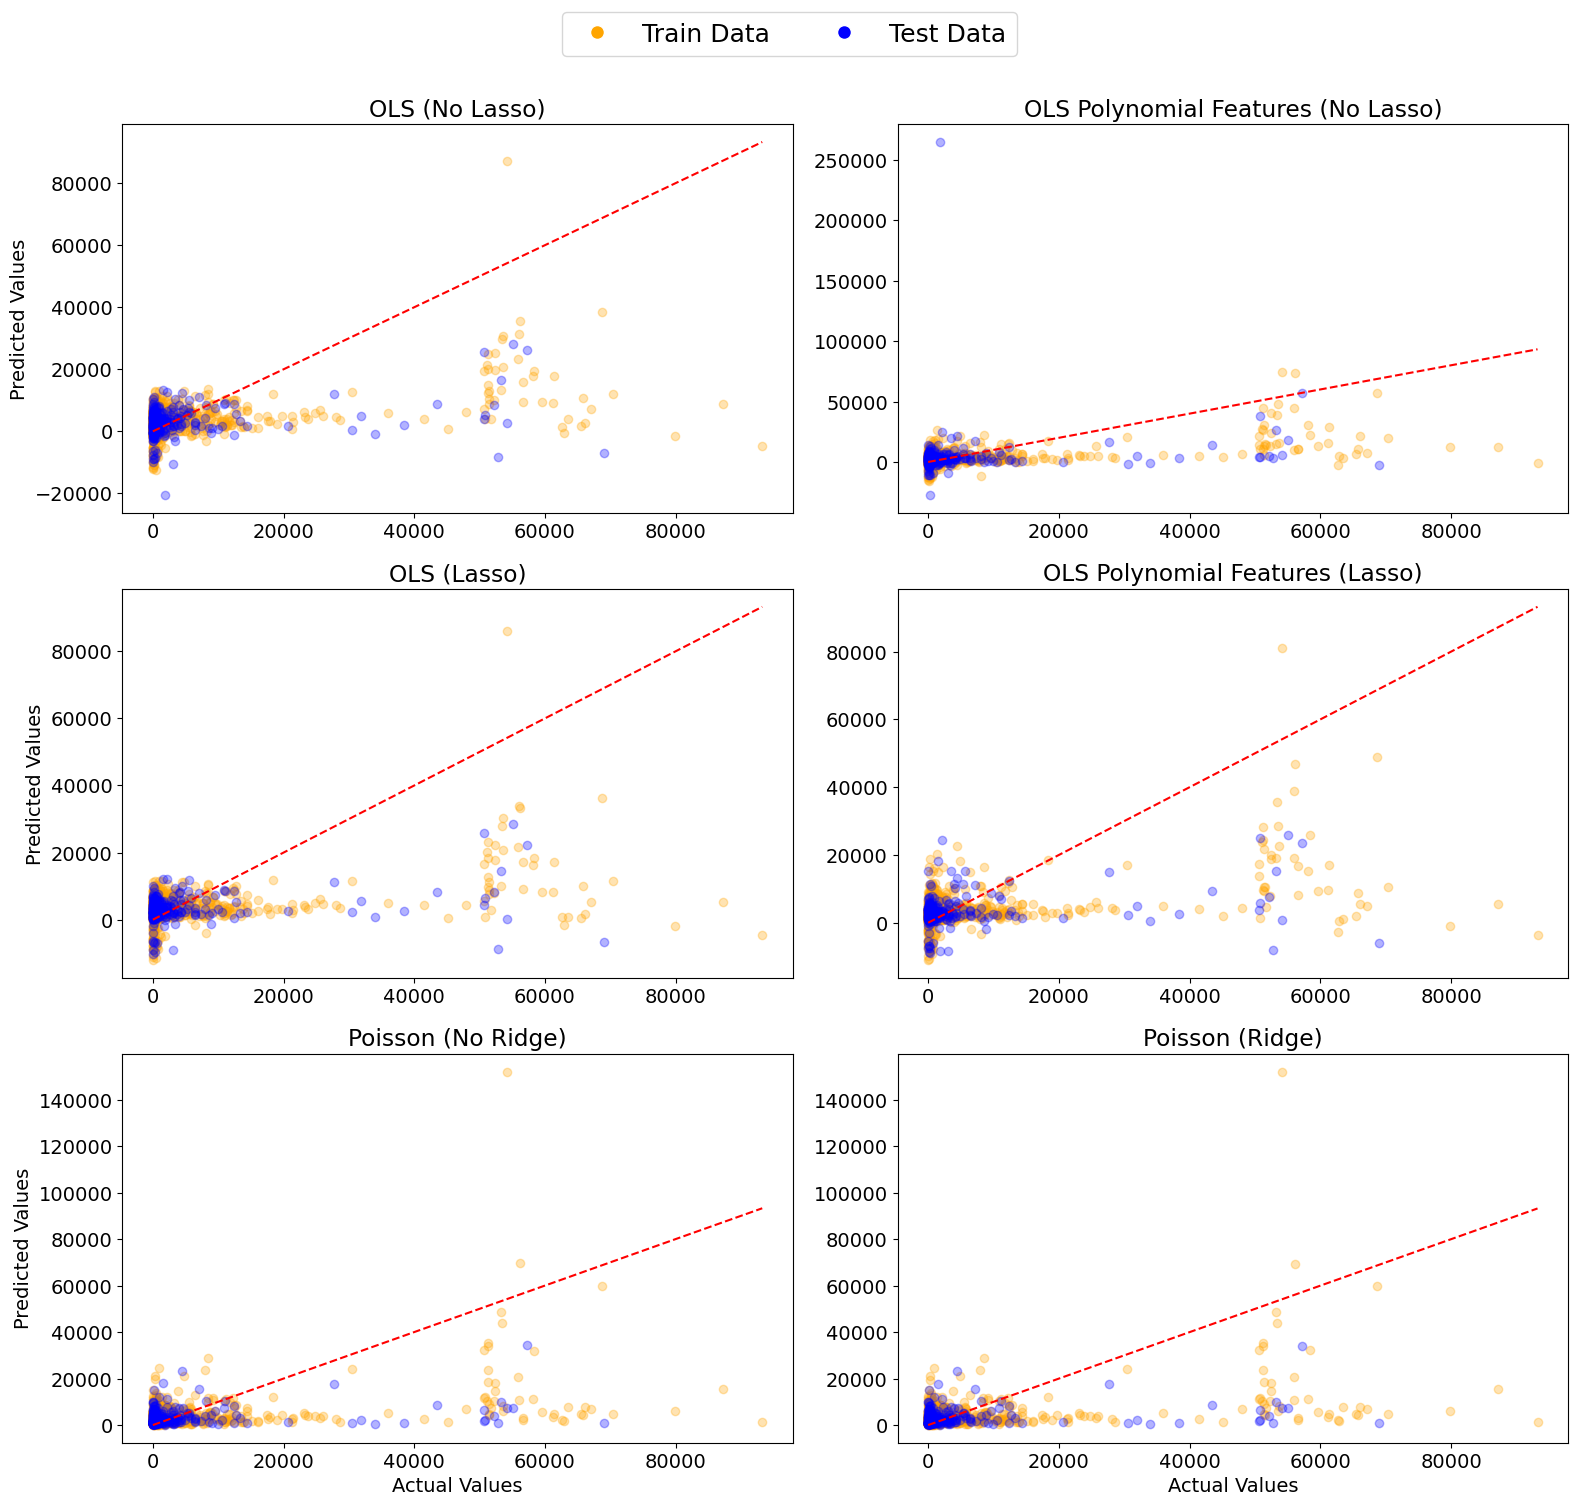

In [18]:
# Ensure the output directory exists
output_dir = "Output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Set global font size for all plot elements
plt.rcParams.update({'font.size': 14})

# Set up the plotting area with 3 rows and 2 columns
plt.figure(figsize=(16, 16)) 

# Define the desired order of models and their corresponding titles
model_titles = {
    'OLS': 'OLS (No Lasso)',
    'OLS Polynomial Features': 'OLS Polynomial Features (No Lasso)',
    'LASSO': 'OLS (Lasso)',
    'LASSO Polynomial Features': 'OLS Polynomial Features (Lasso)',
    'Poisson Alpha 0': 'Poisson (No Ridge)',
    'Poisson': 'Poisson (Ridge)'
}

# Sort model_results according to the desired order
sorted_model_results = sorted(model_results, key=lambda x: list(model_titles.keys()).index(x[0]))

# Plot predicted vs. actual values for each model
for idx, (model_name, y_train, y_train_pred, y_test, y_test_pred) in enumerate(sorted_model_results):
    ax = plt.subplot(3, 2, idx + 1)  # Create a subplot for each model (3 rows, 2 columns)
    
    # Calculate overall min and max values for the trend line
    min_val = min(y_train.min(), y_test.min())
    max_val = max(y_train.max(), y_test.max())
    
    # Plot the train data first, then the test data to ensure test data is on top
    ax.scatter(y_train, y_train_pred, alpha=0.3, color='orange', label='Train Data')
    ax.scatter(y_test, y_test_pred, alpha=0.3, color='blue', label='Test Data')
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
    
    # Set axis labels
    if idx % 2 == 0:  # Only set y-axis label for the first column
        ax.set_ylabel('Predicted Values')
    if idx >= 4:  # Only set x-axis label for the last row
        ax.set_xlabel('Actual Values')
    
    # Set the title based on the model name and its corresponding title
    ax.set_title(model_titles[model_name])

# Adjust layout for better fit
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# Create custom legend handles with larger markers
custom_lines = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=10, label='Train Data'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Test Data')
]

# Create a single legend at the top of the plot with larger font size, larger marker size, and a box around it
plt.figlegend(handles=custom_lines, loc='upper center', ncol=2, fontsize=18, frameon=True)

# Save the plot as a PDF file
output_path = os.path.join(output_dir, "predict_vs_actual_plot.pdf")
plt.savefig(output_path, format='pdf')

# Display the plot
plt.show()


## Learning Curve

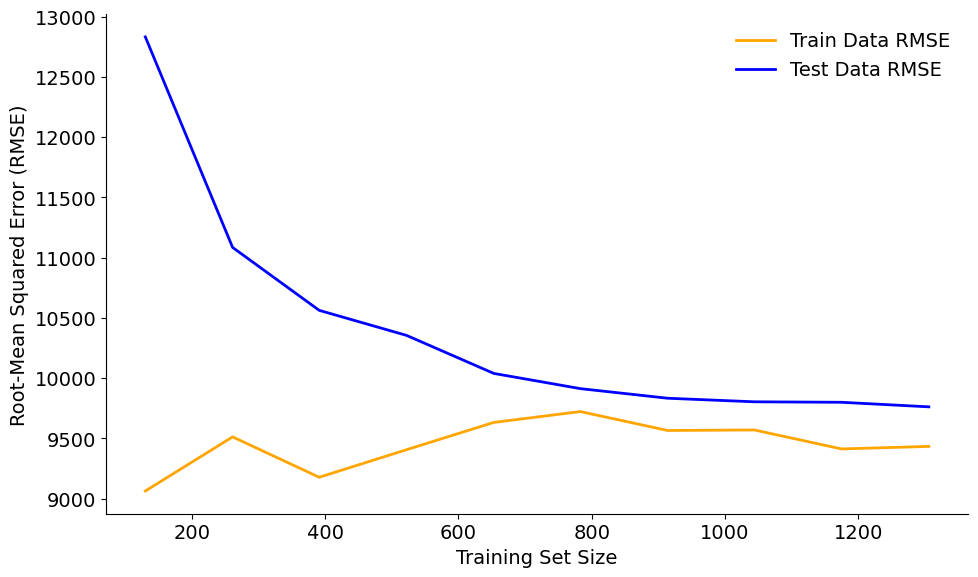

In [19]:
# Define the train_sizes parameter
train_sizes = np.arange(0.1, 1.1, 0.1)  # From 10% to 100% of the data in 10 steps

# Generate learning curve data for OLS
train_sizes_OLS, train_scores_OLS, valid_scores_OLS = learning_curve(
    estimator=gs_OLS,
    X=X_train, 
    y=y_train, 
    train_sizes=train_sizes, 
    cv=10, 
    scoring='neg_mean_squared_error',  # Use MSE as the metric
    n_jobs=-1,
    shuffle=True,  # Randomly shuffle data before splitting into batches
    random_state=random_state
)

# Calculate RMSE from negative MSE values
train_rmse_OLS = np.sqrt(-train_scores_OLS.mean(axis=1))
valid_rmse_OLS = np.sqrt(-valid_scores_OLS.mean(axis=1))

# Plotting the learning curve (set size)
plt.figure(figsize=(10, 6))

# Plot RMSE for training and validation
plt.plot(train_sizes_OLS, train_rmse_OLS, label='Train Data RMSE', color='orange', linewidth=2)
plt.plot(train_sizes_OLS, valid_rmse_OLS, label='Test Data RMSE', color='blue', linewidth=2)

# Set labels and font sizes
plt.xlabel('Training Set Size', fontsize=14)
plt.ylabel('Root-Mean Squared Error (RMSE)', fontsize=14)

# Customize ticks font size
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Customize legend with font size 14 and remove the box around it
plt.legend(loc='upper right', fontsize=14, frameon=False)

# Remove the top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust the plot layout
plt.tight_layout()

# Save the plot as a PDF file in the Output directory
output_path = os.path.join(output_dir, "learning_curve_OLS.pdf")
plt.savefig(output_path, format='pdf')

# Show the plot
plt.show()


# Length of data
For reporting in paper.

In [20]:
len(X_train)

1452

In [21]:
len(X_test)

364